In [7]:
# 新能源汽车发展指数分析（AHP方法）
# 包含数据预处理、判断矩阵构建、权重计算、可视化及结果保存
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.linalg import eig
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']  # 指定默认字体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号('-')显示为方块的问题
# 数据加载与预处理
def load_and_preprocess(file_path):
    """加载并预处理原始数据"""
    df = pd.read_excel(file_path, index_col=0)
    
    # 处理最后一行格式不一致问题
    df.iloc[-1] = df.iloc[-1].apply(lambda x: float(str(x).replace(',','')))
    
    # Min-Max标准化
    df_normalized = (df - df.min()) / (df.max() - df.min())
    return df_normalized.round(4)

#  AHP层次分析法实现
class AHP_Analysis:
    def __init__(self, indicators):
        self.indicators = indicators
        self.matrix = None
        
    def build_matrix(self, matrix_values):
        """构建判断矩阵"""
        self.matrix = np.array(matrix_values)
        return self
    
    def _check_consistency(self):
        """一致性检验"""
        n = self.matrix.shape[0]
        eigenvalues, _ = eig(self.matrix)
        max_eigen = np.max(eigenvalues.real)
        CI = (max_eigen - n) / (n - 1)
        RI = [0, 0, 0.58, 0.90, 1.12, 1.24, 1.32, 1.41][n]
        return CI.real / RI
    
    def calculate_weights(self):
        """计算权重"""
        if self._check_consistency() >= 0.1:
            raise ValueError("一致性检验未通过，请调整判断矩阵")
        
        eigenvalues, eigenvectors = eig(self.matrix)
        max_eigen_idx = np.argmax(eigenvalues.real)
        weights = eigenvectors[:, max_eigen_idx].real
        return weights / weights.sum()
    
    def visualize_matrix(self, save_path="AHP_Matrix.png"):
        """可视化判断矩阵"""
        df_heatmap = pd.DataFrame(
            self.matrix,
            index=self.indicators,
            columns=self.indicators
        )
        
        plt.figure(figsize=(12, 8))
        sns.heatmap(
            df_heatmap, annot=True, fmt=".2f", cmap="Blues",
            linewidths=0.5, cbar=False, annot_kws={"size":10}
        )
        plt.title("AHP判断矩阵热力图（1-9标度法）", fontsize=14, pad=20)
        plt.xticks(rotation=45, ha='right', fontsize=10)
        plt.yticks(rotation=0, fontsize=10)
        plt.tight_layout()
        plt.savefig(save_path, dpi=300)
        plt.close()

# 结果可视化与保存 
def visualize_results(weights, index_series, save_dir="./"):
    """可视化权重和综合指数"""
    # 权重分布柱状图
    weight_df = pd.DataFrame(weights, index=indicators, columns=["权重"])
    weight_df = weight_df.sort_values(by="权重", ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x=weight_df["权重"], y=weight_df.index, palette="viridis")
    plt.title("指标权重分布", fontsize=14)
    plt.xlabel("权重值", fontsize=12)
    plt.ylabel("")
    plt.tight_layout()
    plt.savefig(f"{save_dir}/AHP_Weights.png", dpi=300)
    plt.close()
    
    # 综合指数趋势图
    plt.figure(figsize=(12, 6))
    index_series.plot(linewidth=2, marker='o', markersize=8)
    plt.title("新能源汽车发展指数趋势（2019-2025）", fontsize=14)
    plt.xlabel("日期", fontsize=12)
    plt.ylabel("指数值", fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(f"{save_dir}/Development_Index.png", dpi=300)
    plt.close()

# ================== 主程序 ==================
if __name__ == "__main__":
    raw_data = load_and_preprocess("已处理数据.xls")
    
    # AHP分析配置
    indicators = [
        "公共充电桩数量", "公共充电桩充电电量", "电池装机量",
        "燃料电池产量", "新能源汽车产量", 
        "燃料电池销量", "新能源汽车销量"
    ]
    
    # 基于文献构建的判断矩阵
    ahp_matrix = [
        [1,   3,   5,   7,   5,   7,   7],
        [1/3, 1,   3,   5,   3,   5,   5],
        [1/5, 1/3, 1,   3,   2,   3,   3],
        [1/7, 1/5, 1/3, 1,   1/3, 2,   1],
        [1/5, 1/3, 1/2, 3,   1,   5,   3],
        [1/7, 1/5, 1/3, 1/2, 1/5, 1,   1/3],
        [1/7, 1/5, 1/3, 1,   1/3, 3,   1]
    ]
    
    # 3. 执行AHP分析
    ahp = AHP_Analysis(indicators).build_matrix(ahp_matrix)
    ahp.visualize_matrix()
    weights = ahp.calculate_weights()
    
    # 4. 计算综合指数
    index = raw_data.dot(weights)
    
    # 5. 可视化与保存
    visualize_results(weights, index)
    
    # 保存结果到Excel
    with pd.ExcelWriter("AHP_Results.xlsx") as writer:
        pd.DataFrame(weights, index=indicators, columns=["权重"]).to_excel(writer, sheet_name="权重")
        pd.DataFrame(index, columns=["发展指数"]).to_excel(writer, sheet_name="综合指数")

    print("结果已保存至：")
    print("- AHP_Matrix.png（判断矩阵热力图）")
    print("- AHP_Weights.png（权重分布图）")
    print("- Development_Index.png（指数趋势图）")
    print("- AHP_Results.xlsx（详细数据）")

C:\Users\10414\AppData\Local\Temp\ipykernel_62540\270119765.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weight_df["权重"], y=weight_df.index, palette="viridis")


分析完成！结果已保存至：
- AHP_Matrix.png（判断矩阵热力图）
- AHP_Weights.png（权重分布图）
- Development_Index.png（指数趋势图）
- AHP_Results.xlsx（详细数据）


一致性比例 CR = 0.047 通过

指标权重：
                 权重
公共充电桩数量    0.421502
公共充电桩充电电量  0.227059
电池装机量      0.118103
新能源汽车产量    0.104667
新能源汽车销量    0.050423
燃料电池产量     0.046072
燃料电池销量     0.032174


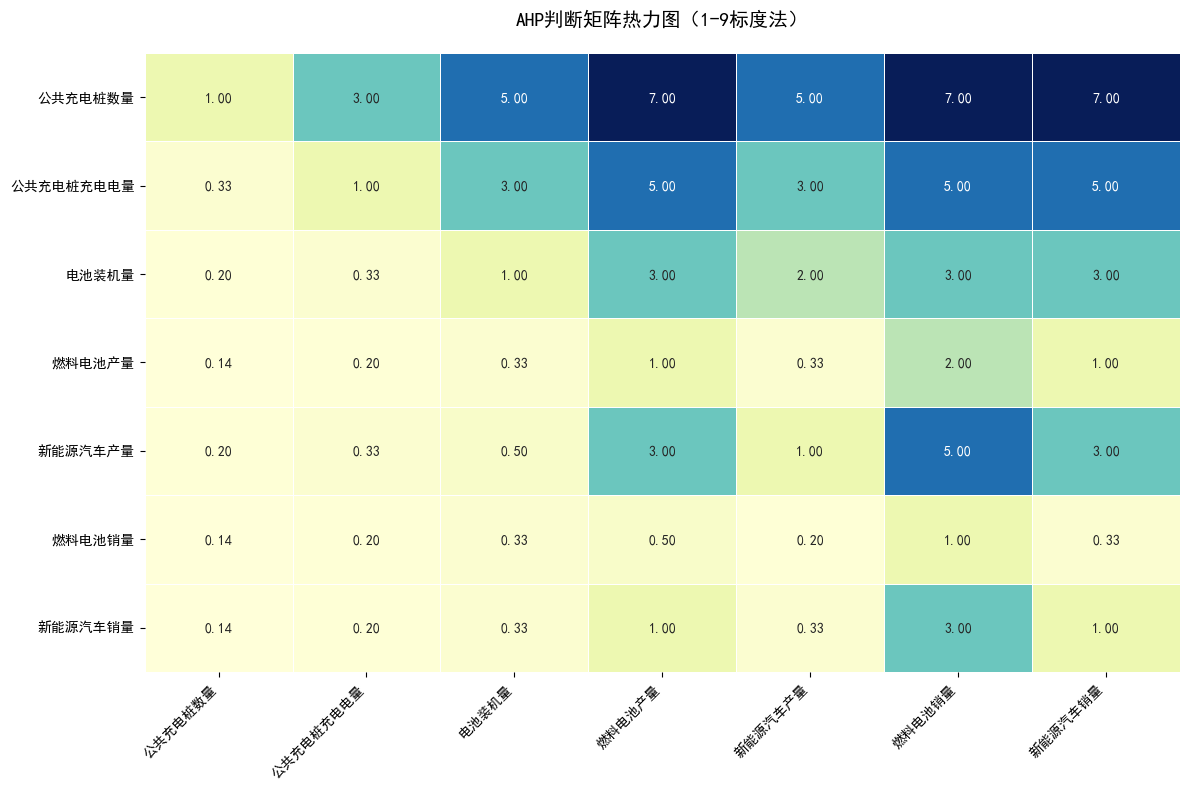

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.linalg import eig
# 在导入plt前设置
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']  # 指定默认字体为黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示异常
# ================== 1. 定义指标和判断矩阵 ==================
# 基于文献《新能源汽车发展评价指标体系研究》的结论
indicators = [
    "公共充电桩数量",
    "公共充电桩充电电量",
    "电池装机量",
    "燃料电池产量",
    "新能源汽车产量",
    "燃料电池销量",
    "新能源汽车销量"
]

# 构造判断矩阵（1-9标度法）
judge_matrix = np.array([
    [1,    3,    5,    7,    5,    7,    7],   # 充电桩数量
    [1/3,  1,    3,    5,    3,    5,    5],   # 充电电量
    [1/5,  1/3,  1,    3,    2,    3,    3],   # 电池装机量
    [1/7,  1/5,  1/3,  1,    1/3,  2,    1],   # 燃料电池产量
    [1/5,  1/3,  1/2,  3,    1,    5,    3],   # 新能源汽车产量
    [1/7,  1/5,  1/3,  1/2,  1/5,  1,    1/3], # 燃料电池销量
    [1/7,  1/5,  1/3,  1,    1/3,  3,    1]    # 新能源汽车销量
])

# ================== 2. 一致性检验 ==================
def check_consistency(matrix):
    """检查判断矩阵的一致性"""
    n = matrix.shape[0]
    eigenvalues, _ = eig(matrix)
    max_eigen = np.max(eigenvalues.real)
    CI = (max_eigen - n) / (n - 1)
    RI = [0, 0, 0.58, 0.90, 1.12, 1.24, 1.32, 1.41][n]  # 标准RI值
    CR = CI / RI
    return CR.real

CR = check_consistency(judge_matrix)
print(f"一致性比例 CR = {CR:.3f} {'通过' if CR < 0.1 else '不通过'}")

# ================== 3. 计算权重 ==================
def calculate_weights(matrix):
    """特征向量法计算权重"""
    eigenvalues, eigenvectors = eig(matrix)
    max_eigen_idx = np.argmax(eigenvalues.real)
    weights = eigenvectors[:, max_eigen_idx].real
    return weights / np.sum(weights)

weights = calculate_weights(judge_matrix)
weight_df = pd.DataFrame(weights, index=indicators, columns=["权重"])
print("\n指标权重：")
print(weight_df.sort_values(by="权重", ascending=False))

# ================== 4. 可视化 ==================
# 4.1 判断矩阵热力图
plt.figure(figsize=(12, 8))
sns.heatmap(pd.DataFrame(judge_matrix, columns=indicators, index=indicators),
            annot=True, fmt=".2f", cmap="YlGnBu",
            linewidths=0.5, cbar=False, annot_kws={"size":10})
plt.title("AHP判断矩阵热力图（1-9标度法）", fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig("AHP_Matrix_Heatmap.png", dpi=300)


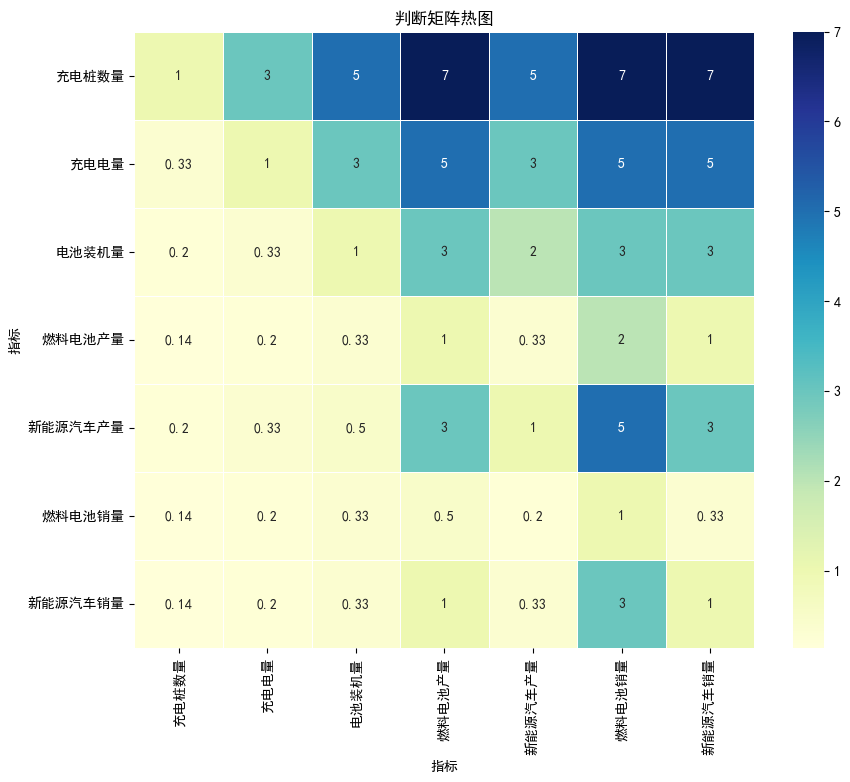

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 构造判断矩阵
judge_matrix = np.array([
    [1,    3,    5,    7,    5,    7,    7],   # 充电桩数量
    [1/3,  1,    3,    5,    3,    5,    5],   # 充电电量
    [1/5,  1/3,  1,    3,    2,    3,    3],   # 电池装机量
    [1/7,  1/5,  1/3,  1,    1/3,  2,    1],   # 燃料电池产量
    [1/5,  1/3,  1/2,  3,    1,    5,    3],   # 新能源汽车产量
    [1/7,  1/5,  1/3,  1/2,  1/5,  1,    1/3], # 燃料电池销量
    [1/7,  1/5,  1/3,  1,    1/3,  3,    1]    # 新能源汽车销量
])

# 设置指标标签
labels = [
    '充电桩数量', '充电电量', '电池装机量', 
    '燃料电池产量', '新能源汽车产量', '燃料电池销量', '新能源汽车销量'
]

# 绘制热图
plt.figure(figsize=(10, 8))
sns.heatmap(judge_matrix, annot=True, cmap='YlGnBu', linewidths=0.5, xticklabels=labels, yticklabels=labels)
plt.title('判断矩阵热图')
plt.xlabel('指标')
plt.ylabel('指标')
plt.show()

In [9]:
import pandas as pd
import numpy as np

# 构造判断矩阵
judge_matrix = np.array([
    [1,    3,    5,    7,    5,    7,    7],   # 充电桩数量
    [1/3,  1,    3,    5,    3,    5,    5],   # 充电电量
    [1/5,  1/3,  1,    3,    2,    3,    3],   # 电池装机量
    [1/7,  1/5,  1/3,  1,    1/3,  2,    1],   # 燃料电池产量
    [1/5,  1/3,  1/2,  3,    1,    5,    3],   # 新能源汽车产量
    [1/7,  1/5,  1/3,  1/2,  1/5,  1,    1/3], # 燃料电池销量
    [1/7,  1/5,  1/3,  1,    1/3,  3,    1]    # 新能源汽车销量
])

# 设置指标标签
labels = [
    '充电桩数量', '充电电量', '电池装机量', 
    '燃料电池产量', '新能源汽车产量', '燃料电池销量', '新能源汽车销量'
]

# 创建DataFrame
df = pd.DataFrame(judge_matrix, index=labels, columns=labels)

# 设置表格样式
styled_df = df.style.set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#E8F5E9'), ('color', '#000000')]},
    {'selector': 'td', 'props': [('background-color', '#E8F5E9'), ('color', '#000000')]}
]).set_caption('判断矩阵')

# 显示表格
styled_df

,充电桩数量,充电电量,电池装机量,燃料电池产量,新能源汽车产量,燃料电池销量,新能源汽车销量
充电桩数量,1.000000,3.000000,5.000000,7.000000,5.000000,7.000000,7.000000
充电电量,0.333333,1.000000,3.000000,5.000000,3.000000,5.000000,5.000000
电池装机量,0.200000,0.333333,1.000000,3.000000,2.000000,3.000000,3.000000
燃料电池产量,0.142857,0.200000,0.333333,1.000000,0.333333,2.000000,1.000000
新能源汽车产量,0.200000,0.333333,0.500000,3.000000,1.000000,5.000000,3.000000
燃料电池销量,0.142857,0.200000,0.333333,0.500000,0.200000,1.000000,0.333333
新能源汽车销量,0.142857,0.200000,0.333333,1.000000,0.333333,3.000000,1.000000


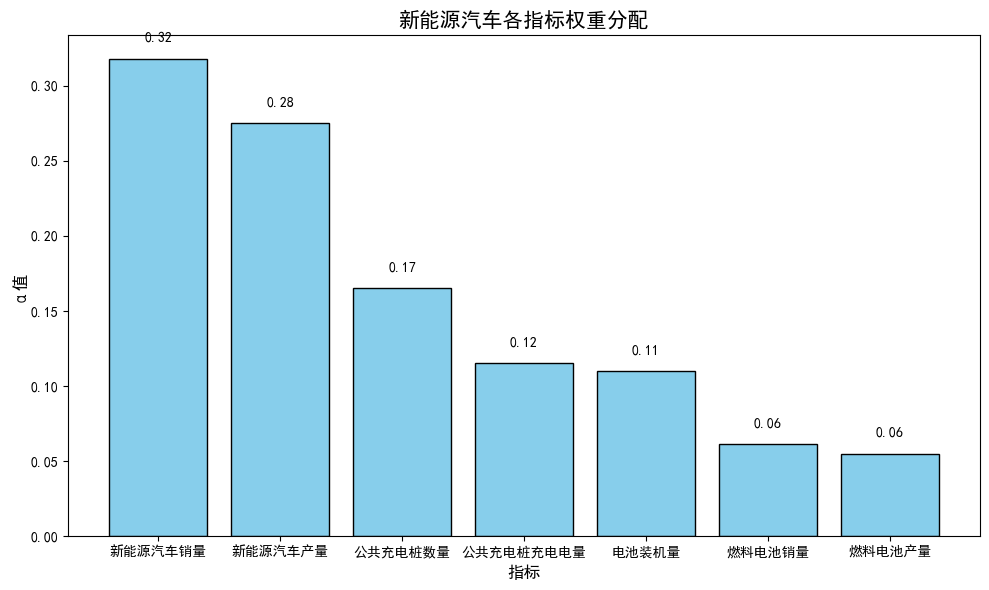

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 指标名称
indicators = [
    '新能源汽车销量',
    '新能源汽车产量',
    '公共充电桩数量',
    '公共充电桩充电电量',
    '电池装机量',
    '燃料电池销量',
    '燃料电池产量'
]

# 调整后的α值
alpha_values = [0.318, 0.275, 0.165,0.115, 0.11,0.061,0.055]

# 创建图形和坐标轴
fig, ax = plt.subplots(figsize=(10, 6))

# 绘制条形图
bars = ax.bar(indicators, alpha_values, color='skyblue', edgecolor='black')

# 添加标题和标签
ax.set_title('新能源汽车各指标权重分配', fontsize=15)
ax.set_xlabel('指标', fontsize=12)
ax.set_ylabel('α值', fontsize=12)

# 添加数值标签
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.2f}',
            ha='center', va='bottom')

# 调整布局
plt.tight_layout()

# 显示图形
plt.show()